# pip install 
- yfinance 
- pandas 
- numpy 
- matplotlib 
- seaborn

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# 한글 폰트 설정 (Mac/Windows 공용 설정)
import matplotlib
import platform
if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    matplotlib.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 1. 기간 및 데이터 소스 설정
end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now() - timedelta(days=5*365)).strftime('%Y-%m-%d')
ticker = "HG=F" # COMEX 구리 선물

print(f"[{ticker}] 데이터를 {start_date}부터 {end_date}까지 수집합니다.")

# 2. 데이터 다운로드
copper_data = yf.download(ticker, start=start_date, end=end_date)

# 3. 분석용 컬럼 추가: 일일 수익률 (%)
copper_data['Daily Return'] = copper_data['Close'].pct_change() * 100

# 4. CSV 파일로 저장
file_name = f"copper_5yr_analysis_{end_date}.csv"
copper_data.to_csv(file_name)
print(f"--------------------------------------------------")
print(f"성공적으로 데이터를 수집하고 '{file_name}'으로 저장했습니다.")
print(f"데이터 상위 5행:")
display(copper_data.head())

[HG=F] 데이터를 2021-03-29부터 2026-03-28까지 수집합니다.


[*********************100%***********************]  1 of 1 completed

--------------------------------------------------
성공적으로 데이터를 수집하고 'copper_5yr_analysis_2026-03-28.csv'으로 저장했습니다.
데이터 상위 5행:


Price,Close,High,Low,Open,Volume,Daily Return
Ticker,HG=F,HG=F,HG=F,HG=F,HG=F,
Date,,,,,,
2021-03-29,4.0430,4.0690,4.020,4.0650,441,NaN
2021-03-30,3.9830,4.0355,3.975,4.0355,1052,-1.484051
2021-03-31,4.0030,4.0115,3.989,4.0060,289,0.502128
2021-04-01,4.0035,4.0150,3.985,3.9850,815,0.012496
2021-04-05,4.1490,4.1620,4.054,4.0540,243,3.634325


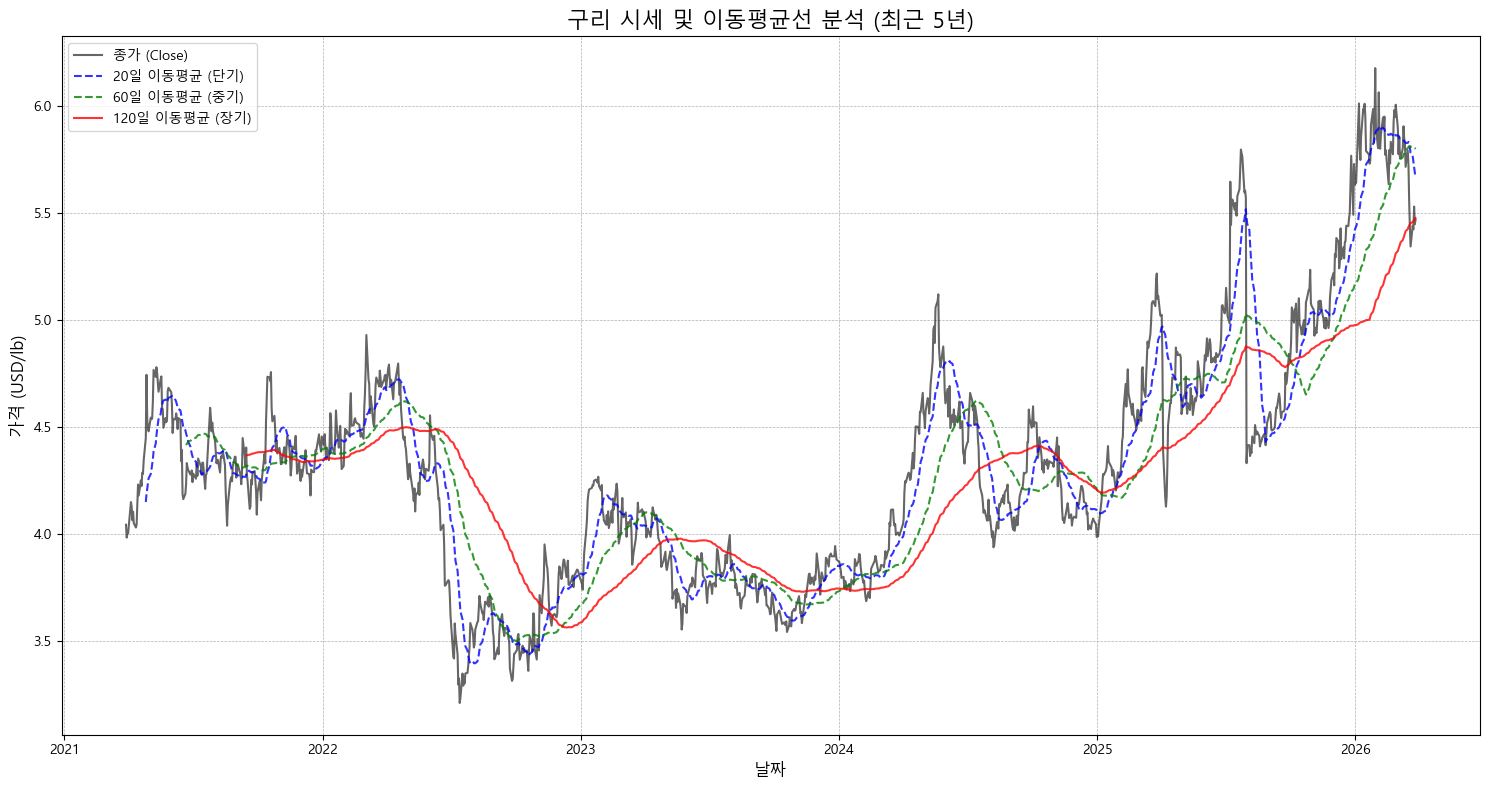

분석: 단기 이동평균선이 장기 이동평균선을 상향 돌파(골든크로스)하면 상승 추세, 하향 돌파(데드크로스)하면 하락 추세로 해석합니다.


In [2]:
# 5. 이동평균선(Moving Average) 계산
copper_data['MA20'] = copper_data['Close'].rolling(window=20).mean()
copper_data['MA60'] = copper_data['Close'].rolling(window=60).mean()
copper_data['MA120'] = copper_data['Close'].rolling(window=120).mean()

# 6. 시각화
plt.figure(figsize=(15, 8))
plt.plot(copper_data['Close'], label='종가 (Close)', color='black', alpha=0.6, linewidth=1.5)
plt.plot(copper_data['MA20'], label='20일 이동평균 (단기)', color='blue', linestyle='--', alpha=0.8)
plt.plot(copper_data['MA60'], label='60일 이동평균 (중기)', color='green', linestyle='--', alpha=0.8)
plt.plot(copper_data['MA120'], label='120일 이동평균 (장기)', color='red', linestyle='-', alpha=0.8)

plt.title('구리 시세 및 이동평균선 분석 (최근 5년)', fontsize=16)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('가격 (USD/lb)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

print("분석: 단기 이동평균선이 장기 이동평균선을 상향 돌파(골든크로스)하면 상승 추세, 하향 돌파(데드크로스)하면 하락 추세로 해석합니다.")

구리 일일 수익률 요약 통계:
count    1258.000000
mean        0.039827
std         1.763359
min       -22.253142
25%        -0.935219
50%         0.023842
75%         1.038464
max        13.251080
Name: Daily Return, dtype: float64
--------------------------------------------------


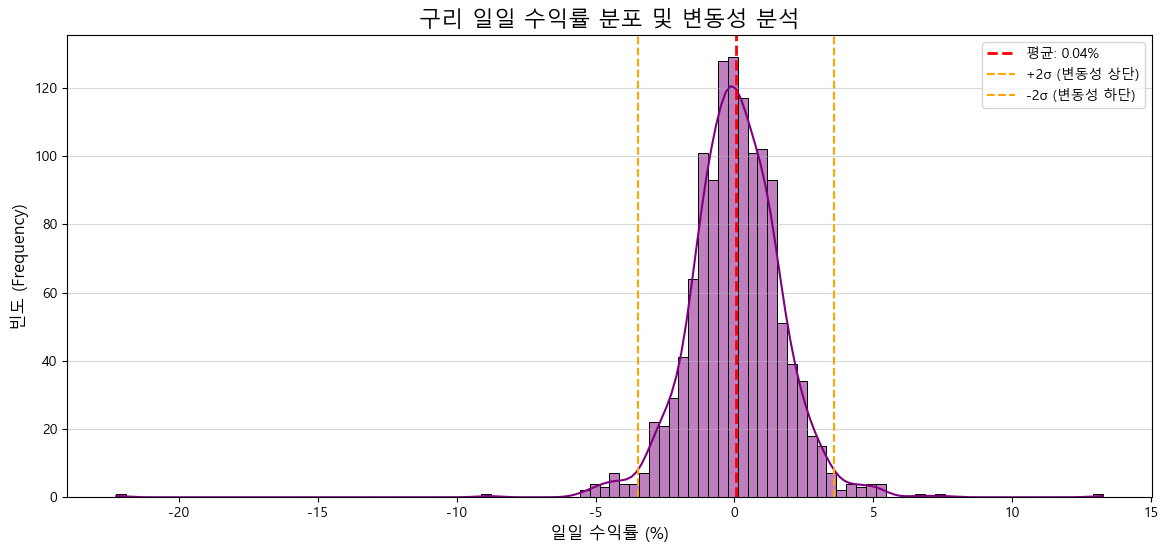

분석: 수익률 분포가 0%를 중심으로 좁고 높게 솟을수록 안정적이며, 양옆으로 넓게 퍼질수록 변동성(리스크)이 큽니다.
현재 95%의 확률로 구리의 일일 가격 변동은 -3.49% ~ 3.57% 사이에 위치합니다.


In [3]:
# 7. 기본 통계량 확인
returns_stats = copper_data['Daily Return'].describe()
print("구리 일일 수익률 요약 통계:")
print(returns_stats)
print(f"--------------------------------------------------")

# 8. 시각화 (히스토그램 & 커널 밀도 추정)
plt.figure(figsize=(14, 6))

# 히스토그램
sns.histplot(copper_data['Daily Return'].dropna(), bins=100, kde=True, color='purple', alpha=0.5)

# 통계 지표 표시 (평균, ±2 표준편차)
mean_ret = returns_stats['mean']
std_ret = returns_stats['std']
plt.axvline(mean_ret, color='red', linestyle='dashed', linewidth=2, label=f'평균: {mean_ret:.2f}%')
plt.axvline(mean_ret + 2*std_ret, color='orange', linestyle='--', label=f'+2σ (변동성 상단)')
plt.axvline(mean_ret - 2*std_ret, color='orange', linestyle='--', label=f'-2σ (변동성 하단)')

plt.title('구리 일일 수익률 분포 및 변동성 분석', fontsize=16)
plt.xlabel('일일 수익률 (%)', fontsize=12)
plt.ylabel('빈도 (Frequency)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

print(f"분석: 수익률 분포가 0%를 중심으로 좁고 높게 솟을수록 안정적이며, 양옆으로 넓게 퍼질수록 변동성(리스크)이 큽니다.")
print(f"현재 95%의 확률로 구리의 일일 가격 변동은 {mean_ret - 2*std_ret:.2f}% ~ {mean_ret + 2*std_ret:.2f}% 사이에 위치합니다.")

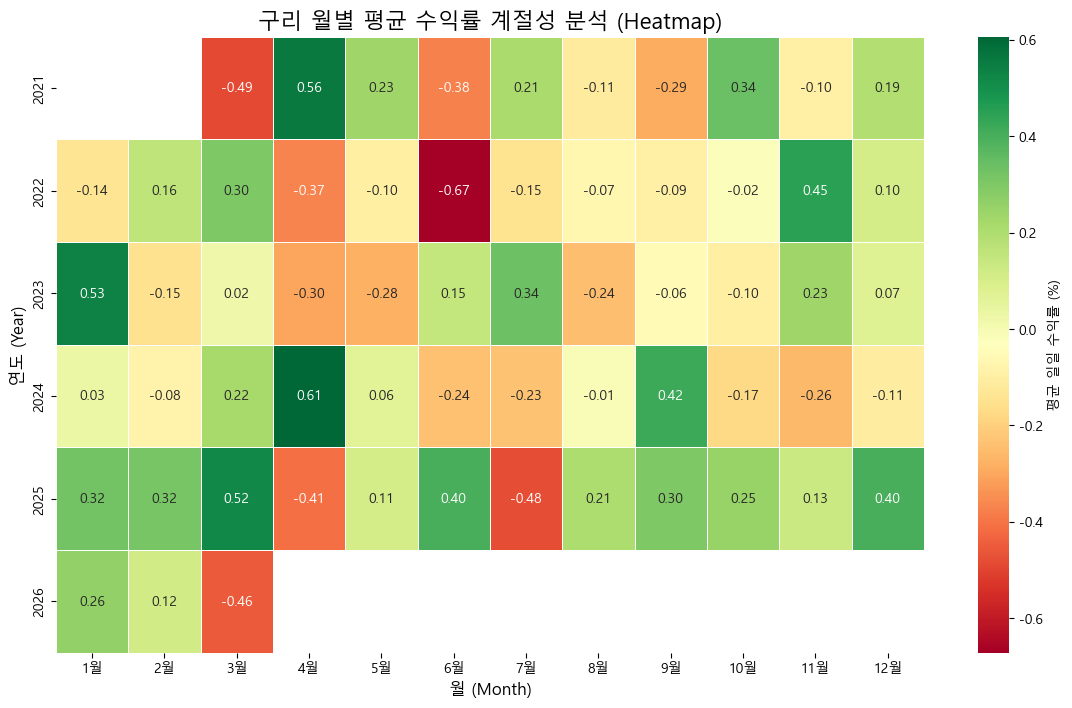

분석: 진한 초록색일수록 해당 월에 수익률이 높았고, 진한 빨간색일수록 낮았습니다.


In [6]:
# 9. 월별 수익률 데이터 재구성 (Pivot Table)
# yfinance의 MultiIndex 구조를 처리하기 위해 컬럼을 단순화합니다.
if isinstance(copper_data.columns, pd.MultiIndex):
    copper_data.columns = copper_data.columns.get_level_values(0)

season_df = copper_data[['Daily Return']].copy()
season_df['Year'] = season_df.index.year
season_df['Month'] = season_df.index.month

# 연도별, 월별 평균 일일 수익률 계산
# values, index, columns에 들어가는 이름이 데이터프레임의 컬럼명과 정확히 일치해야 합니다.
pivot_table = season_df.pivot_table(values='Daily Return', index='Year', columns='Month', aggfunc='mean')

# 10. 시각화 (Heatmap)
plt.figure(figsize=(14, 8))
# sns.heatmap은 기본적으로 pivot_table의 index와 columns를 축 레이블로 사용합니다.
sns.heatmap(pivot_table, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=.5, cbar_kws={'label': '평균 일일 수익률 (%)'})

plt.title('구리 월별 평균 수익률 계절성 분석 (Heatmap)', fontsize=16)
plt.xlabel('월 (Month)', fontsize=12)
plt.ylabel('연도 (Year)', fontsize=12)

# plt.xticks(range(1, 13)) 이 부분은 히트맵의 칸(cell) 중앙과 맞지 않아 어색하게 보일 수 있으므로 
# Seaborn이 자동으로 생성한 레이블을 사용하는 것이 가장 정확합니다. 
# 만약 1~12월을 강제 표시하고 싶다면 아래와 같이 수정합니다.
plt.xticks(np.arange(12) + 0.5, labels=[f"{m}월" for m in range(1, 13)]) 

plt.show()

print("분석: 진한 초록색일수록 해당 월에 수익률이 높았고, 진한 빨간색일수록 낮았습니다.")


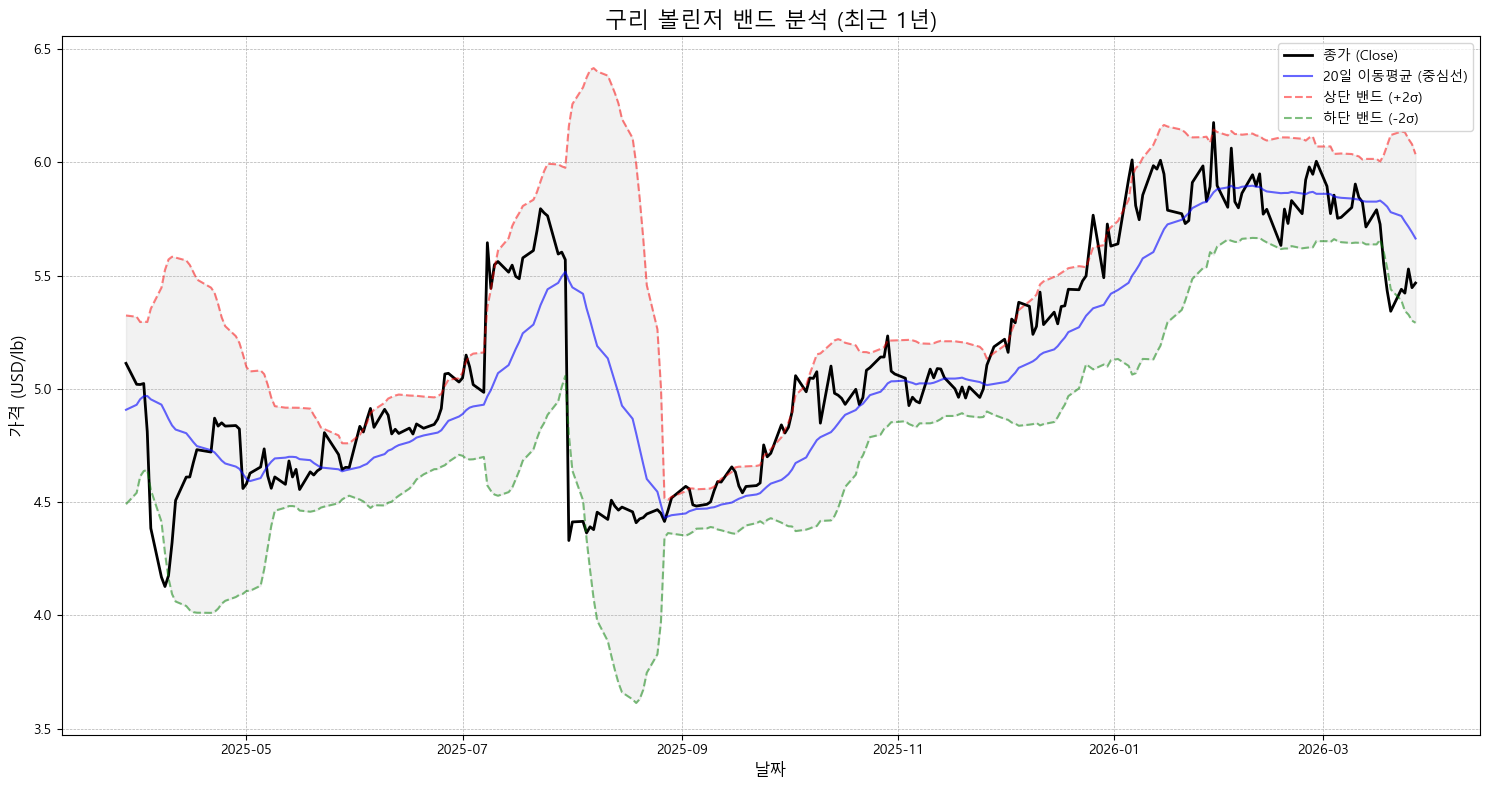

분석: 통계적으로 가격의 95%는 밴드 내에 위치합니다. 가격이 상단 밴드에 닿으면 과매수(고점), 하단 밴드에 닿으면 과매도(저점) 상태로 해석할 수 있습니다.


In [7]:
# 11. 볼린저 밴드 계산 (20일 이동평균 ± 2 표준편차)
copper_data['Upper Band'] = copper_data['MA20'] + (copper_data['Close'].rolling(window=20).std() * 2)
copper_data['Lower Band'] = copper_data['MA20'] - (copper_data['Close'].rolling(window=20).std() * 2)

# 12. 시각화 (최근 1년 데이터만 그려서 자세히 보기)
recent_year = (datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d')
plot_data = copper_data.loc[recent_year:]

plt.figure(figsize=(15, 8))
plt.plot(plot_data['Close'], label='종가 (Close)', color='black', linewidth=2)
plt.plot(plot_data['MA20'], label='20일 이동평균 (중심선)', color='blue', alpha=0.6)
plt.plot(plot_data['Upper Band'], label='상단 밴드 (+2σ)', color='red', linestyle='--', alpha=0.5)
plt.plot(plot_data['Lower Band'], label='하단 밴드 (-2σ)', color='green', linestyle='--', alpha=0.5)

# 밴드 사이 색칠
plt.fill_between(plot_data.index, plot_data['Upper Band'], plot_data['Lower Band'], color='gray', alpha=0.1)

plt.title('구리 볼린저 밴드 분석 (최근 1년)', fontsize=16)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('가격 (USD/lb)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

print("분석: 통계적으로 가격의 95%는 밴드 내에 위치합니다. 가격이 상단 밴드에 닿으면 과매수(고점), 하단 밴드에 닿으면 과매도(저점) 상태로 해석할 수 있습니다.")